In [2]:
import numpy as np
import os
import time
from pathlib import Path
import optuna
import matplotlib.pyplot as plt

import matplotlib.patches as ps
print(np.__version__)

1.26.4


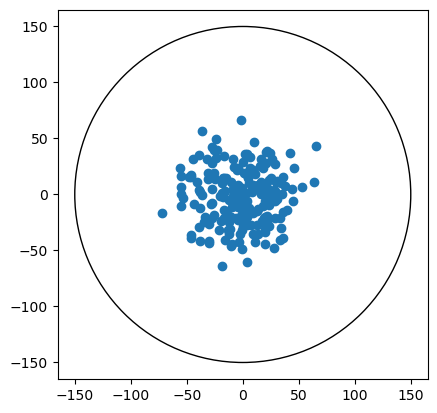

In [9]:
def wait_for_file(file_path, timeout=600, check_interval=5):

    start = time.time()

    while not os.path.exists(file_path):
        if time.time() - start_time > timeout:
            raise TimeoutError(f"File {file_path} was not created within {timeout} seconds.")
        time.sleep(check_interval)

def wait_for_file_creation(file_path, check_interval=10):
    
    print(f"Waiting for file: {file_path}")

    while not os.path.exists(file_path):
        time.sleep(check_interval)
    print(f"File found: {file_path}")

def target_function(x):

    target = np.sin(0.5*x)

    return target

def mse_loss(x, y):

    x_norm = (x - x.mean()) / (x.std() + 1e-8)
    y_norm = (y - y.mean()) / (y.std() + 1e-8)

    mse = np.mean((y_norm - x_norm)**2, axis=1)
    
    return mse

def sample_positions(means, covs, weights, radius, N):

    positions = []
    cum_sum_weights = np.cumsum(weights)

    while len(positions) < N:

        u = np.random.uniform(0, 1) * cum_sum_weights[-1]
        component = np.searchsorted(cum_sum_weights, u)

        x = np.random.multivariate_normal(mean=means[component], cov=covs[component])

        if np.sqrt(x[0]**2 + x[1]**2) < radius:
            positions.append(x)

    return np.vstack(positions)

def suggest_mean(trial, prefix, radius):

    theta = trial.suggest_float(f"{prefix}_theta", 0, 2*np.pi)
    u = trial.suggest_float(f"{prefix}_u", 0, 1)

    mean_r = radius*np.sqrt(u)
    mean_x = mean_r*np.cos(theta)
    mean_y = mean_r*np.sin(theta)

    return np.array([mean_x, mean-y])

def suggest_diagonal_spd(trial, prefix, log_std_bounds):

    L = np.eye(2, 2)

    log_std = trial.suggest_float(f"{prefix}_log_std", *log_std_bounds)
    std_sq = np.exp(log_std) ** 2

    return std_sq*L
    
radius = 150.0
n_a = 200

std_sq = (radius / 6.0)**2

mean = [np.array([0.0, 0.0])]
cov = [std_sq*np.eye(2)]
weight = [1.0]
pos = sample_positions(mean, cov, weight, radius, n_a)

circle_kwargs = {
    "xy": (0.0, 0.0),
    "radius": radius,
    "fill": None
}

plt.scatter(*pos.T)
ax = plt.gca()
ax.add_patch(ps.Circle(**circle_kwargs))
ax.set_aspect("equal")

In [8]:
from jobs import slurm_single_IV

ROOT = Path("/home/hd/hd_hd/hd_gy283/kmc_project")
WS_DIR = Path("/gpfs/bwfor/work/ws/hd_gy283-my_data")

def find_node_distribution(
    K, 
    radius, n_a, 
    min_V, max_V,
    input_idx, output_idx, 
    c_indices, c_volts,
    num_points, num_intervals, eq_steps, sim_steps, samples_per_trial, 
    exp_folder_name, 
    ROOT=Path("/home/hd/hd_hd/hd_gy283/kmc_project"), 
    WS_DIR=Path("/gpfs/bwfor/work/ws/hd_gy283-my_data"),
    BINARY=Path("/home/hd/hd_hd/hd_gy283/kmc_project/build/kmc_project"),
    SLURM_SCRIPT=Path("/home/hd/hd_hd/hd_gy283/kmc_project/slurm/scripts/single_curve.sh"),
    OUT_DIR=Path("/home/hd/hd_hd/hd_gy283/kmc_project/slurm_out")
):
    
    EXP_DIR = WS_DIR/exp_folder_name
    EXP_DIR.mkdir(parents=True, exist_ok=True)

    OUT_DIR.mkdir(parents=True, exist_ok=True)

    std_min = radius / 3.0
    std_max = radius / 2.0

    log_std_bounds = (np.log(std_min), np.log(std_max))

    def objective(trial):

        node_dist_folder = EXP_DIR/f"trial_{trial.number}"
        node_dist_folder.mkdir(parents=True, exist_ok=True)

        means = []
        covs = []
        weights = []

        raw_weights = []
        for k in range(K):
            means.append(suggest_mean(trial=trial, prefix=f"mu_{k}", radius=radius))
            covs.append(suggest_diagonal_spd(trial=trial, prefix=f"cov_{k}", log_std_bounds=log_std_bounds))
            raw_weight = trial.suggest_float(f"raw_w_{k}", 0.0, 1.0)
            raw_weights.append(raw_weight)

        raw_weight_sum = sum(raw_weights)
        weights = [w / raw_weight_sum for w in raw_weights]

        losses = 0
        for s in range(samples_per_trial):
            X = sample_positions(means, covs, weights, radius, n_a)
            trial_node_dist = f"acceptors_trial={trial.number}_sample={s}.txt"
            with open(str(node_dist_folder) + f"/{trial_node_dist}", "w") as f:
                for p in X:
                    f.write(f"{p[0]}\t{p[1]}\n")

            file_name = f"curve_trial={trial.number}_sample={s}"
            seed = np.random.randint(low=0, high=1_000_000)
            slurm_single_IV(
                num_points,
                input_idx,
                output_idx,
                c_indices,
                c_volts,
                min_V,
                max_V,
                eq_steps,
                sim_steps,
                num_intervals,
                seed,
                Path("/home/hd/hd_hd/hd_gy283/kmc_project/configs/config.txt"),
                EXP_DIR/f"acceptors_trial={trial.number}_sample={s}.txt",
                Path("/home/hd/hd_hd/hd_gy283/kmc_project/configs/donors.txt"),
                Path("/home/hd/hd_hd/hd_gy283/kmc_project/configs/electrodes.txt"),
                Path(EXP_DIR),
                file_name,
                WS_DIR,
                BINARY,
                SLURM_SCRIPT,
                OUT_DIR
            )
            
            NPZ_FILE = EXP_DIR/f"curve_trial={trial.number}_sample={s}.npz"
            wait_for_file_creation(NPZ_FILE, check_interval=20)

            data = np.load(file=NPZ_FILE)
            data_points = data["current"]
            vs = np.linspace(min_V, max_V, num_points)
            target = target_function(vs)

            losses += mse_loss(data_points, target)

        mean_loss = total_loss / max(1, samples_per_trial)
        print('\x1b[6;30;42m' + f'{trial.number}] Finished with score: {total_loss}' + '\x1b[0m')

        return mean_loss

    tpe = optuna.samplers.TPESampler(multivariate=True, group=True, n_startup_trials=n_startup_trials)
    study = optuna.create_study(direction="minimize", sampler=tpe)
    study.optimize(objective, n_trials=n_trials)

    return study